# UNIDAD 2: Probabilidad, Teoría de Conjuntos y Combinatoria

**Duración:** 2 semanas (12 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_2_PROBABILIDAD_COMBINATORIA.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **Estadística Descriptiva y EDA** (Unidad 1) — las frecuencias relativas de una muestra son la antesala empírica del concepto de probabilidad; aquí se formaliza ese límite.
- **Teoría de conjuntos básica** — unión, intersección, complemento y diferencia, para manipular eventos como subconjuntos del espacio muestral y aplicar las leyes de De Morgan.
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica y Conceptos Clave

La **Teoría de la Probabilidad** proporciona el marco matemático formal para cuantificar la incertidumbre y razonar bajo información incompleta. En la Ingeniería en Inteligencia Artificial y Nanotecnología, la probabilidad permite desde modelar la fluctuación térmica de nanopartículas en suspensión coloidal hasta calcular la probabilidad posterior en clasificadores bayesianos de imágenes microscópicas.

### 1.1 Experimento Aleatorio, Espacio Muestral y Eventos
* **Experimento Aleatorio ($\mathcal{E}$)**: Proceso cuyo resultado exacto no se puede predecir con certeza antes de su ejecución, pero cuyo conjunto de todos los resultados posibles es conocido.
* **Espacio Muestral ($\Omega$)**: Conjunto de todos los resultados posibles de un experimento aleatorio.
* **Evento o Sucesos ($A \subseteq \Omega$)**: Cualquier subconjunto del espacio muestral.

### 1.2 Álgebra de Conjuntos y Operaciones Eventuales
Las relaciones entre eventos se expresan mediante la teoría de conjuntos:
* **Unión ($A \cup B$)**: Ocurre al menos uno de los dos eventos.
* **Intersección ($A \cap B$)**: Ocurren ambos eventos simultáneamente.
* **Complemento ($A^c$ o $\bar{A}$)**: Ocurre cualquier resultado que no pertenece a $A$.
* **Eventos Mutuamente Excluyentes (Disjuntos)**: $A \cap B = \emptyset$.

Leyes de De Morgan:
$$(A \cup B)^c = A^c \cap B^c, \quad (A \cap B)^c = A^c \cup B^c$$

**Ejemplo verificando De Morgan (dos criterios de falla de un sensor)**: un lote de $10$ sensores nanoelectrónicos de gas, numerados $1$ a $10$, se somete a dos pruebas de falla independientes: $A$ = "falla por deriva de línea base" y $B$ = "falla por saturación del sensor". Supóngase que, tras la caracterización, $A = \{1,2,3,4\}$ y $B = \{3,4,5,6,7\}$ dentro del espacio muestral $\Omega = \{1,2,\dots,10\}$. Enumerando explícitamente cada conjunto:
$$A^c = \{5,6,7,8,9,10\}, \quad B^c = \{1,2,8,9,10\}$$
$$(A \cup B)^c = \Omega \setminus \{1,2,3,4,5,6,7\} = \boxed{\{8,9,10\}}$$
$$A^c \cap B^c = \{5,6,7,8,9,10\} \cap \{1,2,8,9,10\} = \boxed{\{8,9,10\}}$$
Ambos conjuntos coinciden elemento a elemento, verificando numéricamente $(A \cup B)^c = A^c \cap B^c$ sobre este espacio muestral discreto.

In [2]:
## Verificacion de la Primera Ley de De Morgan con conteo explicito de sensores
omega = set(range(1, 11))  # 10 sensores nanoelectronicos de gas

A = {1, 2, 3, 4}       # sensores que fallan por deriva de linea base
B = {3, 4, 5, 6, 7}    # sensores que fallan por saturacion

A_c = omega - A
B_c = omega - B

complemento_union = omega - (A | B)
interseccion_complementos = A_c & B_c

primera_ley_de_morgan = complemento_union == interseccion_complementos

print(f"(A U B)^c = {complemento_union}")
print(f"A^c ∩ B^c = {interseccion_complementos}")
print(f"¿Se cumple (A U B)^c = A^c ∩ B^c?: {primera_ley_de_morgan}")


(A U B)^c = {8, 9, 10}
A^c ∩ B^c = {8, 9, 10}
¿Se cumple (A U B)^c = A^c ∩ B^c?: True


### 1.3 Axiomas de Kolmogorov
Dado un espacio muestral $\Omega$, una función de probabilidad $P: \mathcal{F} \rightarrow [0, 1]$ asigna a cada evento $A$ un número real sujeto a tres axiomas universales:

1. **Axioma de No-Negatividad**: $P(A) \ge 0$ para todo evento $A$.
2. **Axioma de Normalización**: $P(\Omega) = 1$.
3. **Axioma de Aditividad Contable**: Si $A_1, A_2, A_3, \dots$ es una secuencia de eventos mutuamente excluyentes ($A_i \cap A_j = \emptyset$ para todo $i \neq j$), entonces:
$$P\left( \bigcup_{i=1}^\infty A_i \right) = \sum_{i=1}^\infty P(A_i)$$

Propiedades fundamentales derivadas:
* $P(\emptyset) = 0$
* $P(A^c) = 1 - P(A)$
* Regla General de la Adición: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$

**Ejemplo verificando los 3 Axiomas de Kolmogorov**: un lote de nanopartículas de oro (AuNPs) se clasifica, según el diámetro medido por microscopía electrónica de transmisión (TEM), en tres categorías mutuamente excluyentes: pequeña ($<10\text{ nm}$), mediana ($10$–$20\text{ nm}$) y grande ($>20\text{ nm}$), con probabilidades asignadas $P(\text{pequeña})=0.25$, $P(\text{mediana})=0.45$, $P(\text{grande})=0.30$.
* **Axioma 1 (no-negatividad)**: las tres probabilidades son $\ge 0$.
* **Axioma 2 (normalización)**: $0.25 + 0.45 + 0.30 = \boxed{1.0}$, es decir $P(\Omega)=1$.
* **Axioma 3 (aditividad)**: como "pequeña" y "mediana" son disjuntas, $P(\text{pequeña} \cup \text{mediana}) = P(\text{pequeña}) + P(\text{mediana}) = 0.25 + 0.45 = \boxed{0.70}$.

In [3]:
## Verificacion de los 3 Axiomas de Kolmogorov sobre una clasificacion de AuNPs por tamano
espacio_muestral = {"pequena_menor_10nm": 0.25, "mediana_10_20nm": 0.45, "grande_mayor_20nm": 0.30}

## Axioma 1: no-negatividad
axioma_1_no_negatividad = all(p >= 0 for p in espacio_muestral.values())

## Axioma 2: normalizacion P(Omega) = 1
axioma_2_normalizacion = abs(sum(espacio_muestral.values()) - 1.0) < 1e-9

## Axioma 3: aditividad para eventos disjuntos (pequena U mediana)
p_union_disjunta = espacio_muestral["pequena_menor_10nm"] + espacio_muestral["mediana_10_20nm"]

print(f"Axioma 1 (no-negatividad): {axioma_1_no_negatividad}")
print(f"Axioma 2 (normalizacion), suma = {sum(espacio_muestral.values())}: {axioma_2_normalizacion}")
print(f"Axioma 3, P(pequena U mediana) = {p_union_disjunta}")


Axioma 1 (no-negatividad): True
Axioma 2 (normalizacion), suma = 1.0: True
Axioma 3, P(pequena U mediana) = 0.7


Esta unidad, como el resto del curso, sigue el **Ciclo de Verificación Triple** documentado en `GOVERNANCE.md`: Teoría → Verificación Simbólica (SymPy) → Solución Computacional (SciPy) → Interpretación. La Sección 5 desarrolla el ejemplo aplicado, la Sección 6 lo verifica simbólicamente, y la Sección 7 reproduce el resultado con las herramientas de producción.

## 2. Técnicas de Conteo y Combinatoria

Cuando los resultados de un espacio muestral finito $\Omega$ son equiprobables (regla de Laplace), el cálculo de probabilidades se reduce a contar el número de elementos en eventos y espacios muestrales:
$$P(A) = \frac{|A|}{|\Omega|}$$

**Ejemplo dedicado de la Regla de Laplace (conteo explícito de $|\Omega|$ y $|A|$)**: un lote contiene $15$ nanotubos de carbono indistinguibles al tacto: $9$ de pared simple (SWCNT) y $6$ de pared múltiple (MWCNT). Se selecciona una muestra de $3$ nanotubos al azar para inspección por microscopía. Sea $A$ el evento "los 3 nanotubos seleccionados son SWCNT".

Primero se cuenta el espacio muestral completo, **sin condicionar aún por tipo**: todas las formas de elegir $3$ nanotubos cualesquiera de los $15$ disponibles:
$$|\Omega| = \binom{15}{3} = \boxed{455}$$
Luego se cuenta el evento $A$ por separado: todas las formas de elegir $3$ SWCNT de los $9$ disponibles (sin tocar los MWCNT):
$$|A| = \binom{9}{3} = \boxed{84}$$
Solo ahora, con ambos conteos ya resueltos de forma independiente, se aplica la Regla de Laplace:
$$P(A) = \frac{|A|}{|\Omega|} = \frac{84}{455} \approx \boxed{0.1846}$$

In [4]:
import math

## Regla de Laplace: conteo explicito de |Omega| y |A| antes de dividir
n_total = 15
n_swcnt = 9
n_muestra = 3

## Conteo de |Omega|: todas las formas de elegir 3 nanotubos cualesquiera de 15
omega_tamano = math.comb(n_total, n_muestra)

## Conteo de |A|: todas las formas de elegir 3 SWCNT de los 9 disponibles
A_tamano = math.comb(n_swcnt, n_muestra)

## Regla de Laplace
p_A = A_tamano / omega_tamano

print(f"|Omega| = C(15,3) = {omega_tamano}")
print(f"|A| = C(9,3) = {A_tamano}")
print(f"P(A) = |A|/|Omega| = {p_A:.4f}")


|Omega| = C(15,3) = 455
|A| = C(9,3) = 84
P(A) = |A|/|Omega| = 0.1846


### 2.1 Principios Fundamentales
* **Principio Multiplicativo**: Si una operación consiste en $k$ pasos secuenciales con $n_1, n_2, \dots, n_k$ opciones respectivamente, el número total de formas es $n_1 \times n_2 \times \dots \times n_k$.
* **Principio Aditivo**: Si una alternativa se puede elegir de entre $k$ grupos disjuntos con $n_1, n_2, \dots, n_k$ opciones, el número total de alternativas es $n_1 + n_2 + \dots + n_k$.

### 2.2 Permutaciones
Una **permutación** es una ordenación de un conjunto de objetos donde **el orden sí importa**.

* **Permutación de $n$ objetos distintos**:
$$P(n) = n!$$

* **Permutación de $n$ objetos tomados de $r$ en $r$**:
$$P(n, r) = \frac{n!}{(n-r)!}$$

* **Permutaciones con repetición (multiset)**: Si hay $n_1$ objetos de tipo 1, $n_2$ de tipo 2, $\dots$, $n_k$ de tipo $k$:
$$P(n; n_1, n_2, \dots, n_k) = \frac{n!}{n_1! n_2! \dots n_k!}$$

### 2.3 Combinaciones
Una **combinación** es una selección de $r$ objetos de un conjunto de $n$ objetos donde **el orden no importa**.

$$\binom{n}{r} = C(n, r) = \frac{n!}{r!(n-r)!}$$

Propiedades del coeficiente binomial:
* $\binom{n}{0} = \binom{n}{n} = 1$
* $\binom{n}{r} = \binom{n}{n-r}$
* Teorema del Binomio: $(x + y)^n = \sum_{k=0}^n \binom{n}{k} x^{n-k} y^k$

**Ejemplo verificando el Teorema del Binomio**: un recubrimiento nanocompuesto se forma apilando $n=4$ capas, cada una elegida entre dos tipos de nanopartícula (tipo $X$: óxido de titanio, tipo $Y$: plata). Para verificar la identidad numéricamente (sin atarla a un conteo de capas específico), se evalúa $(x+y)^4$ con $x=2$, $y=3$ expandiendo término a término:
$$(x+y)^4 = \sum_{k=0}^4 \binom{4}{k} x^{4-k} y^k = \binom{4}{0}x^4 + \binom{4}{1}x^3y + \binom{4}{2}x^2y^2 + \binom{4}{3}xy^3 + \binom{4}{4}y^4$$
$$= 16 + 96 + 216 + 216 + 81 = \boxed{625}$$
Comparando contra el cálculo directo $(2+3)^4 = 5^4 = \boxed{625}$: ambos coinciden, confirmando la identidad término a término.

In [5]:
import math

## Verificacion del Teorema del Binomio: expansion termino a termino vs calculo directo
n = 4
x, y = 2, 3

suma_binomio = sum(math.comb(n, k) * (x ** (n - k)) * (y ** k) for k in range(n + 1))
resultado_directo = (x + y) ** n

print(f"Suma de terminos binomiales: {suma_binomio}")
print(f"(x+y)^n calculado directo: {resultado_directo}")
print(f"¿Coinciden?: {suma_binomio == resultado_directo}")


Suma de terminos binomiales: 625
(x+y)^n calculado directo: 625
¿Coinciden?: True


### 2.4 Ejemplos Resueltos de Técnicas de Conteo Aplicadas a Nanotecnología

Reconocer *cuál* técnica de conteo aplica a un problema dado es más difícil que ejecutar la fórmula una vez identificada. Los siguientes cuatro ejemplos cortos, cada uno con una técnica distinta, sirven de referencia rápida antes de enfrentar el banco de ejercicios de la Sección 9.

**Ejemplo A (Principio Multiplicativo — configuración binaria)**: Un arreglo de biosensores nanoelectrónicos tiene $8$ interruptores independientes, cada uno en estado ON/OFF. ¿Cuántas configuraciones distintas del arreglo son posibles?
$$\underbrace{2 \times 2 \times \cdots \times 2}_{8 \text{ veces}} = 2^8 = \boxed{256 \text{ configuraciones}}$$
Es un caso particular del principio multiplicativo donde los $8$ pasos tienen siempre $n_i = 2$ opciones — patrón que reaparece constantemente en el conteo de estados de sistemas binarios (bits de memoria, arreglos de sensores, rutas de un autómata).

**Ejemplo B (Principio Multiplicativo — material compuesto en capas)**: Un material nanocompuesto se fabrica apilando, en orden, una capa base (3 tipos de polímero disponibles), una capa intermedia (4 tipos de nanopartícula catalizadora) y una capa de recubrimiento (2 tipos de sellado). ¿Cuántos materiales distintos pueden ensamblarse?
$$3 \times 4 \times 2 = \boxed{24 \text{ materiales distintos}}$$
A diferencia del Ejemplo A, aquí cada paso tiene un número distinto de opciones ($n_1=3$, $n_2=4$, $n_3=2$) — la esencia del principio multiplicativo es que el número de pasos y de opciones por paso puede variar libremente, siempre que los pasos sean secuenciales e independientes entre sí.

**Ejemplo C (Combinación simple — selección sin orden)**: De un lote de $12$ nanopartículas de plata (AgNPs) sintetizadas, se seleccionan al azar $4$ para un ensayo de dispersión dinámica de luz (DLS). El orden en que se colocan en el equipo no afecta la medición. ¿Cuántas selecciones distintas de $4$ nanopartículas son posibles?
$$\binom{12}{4} = \frac{12!}{4! \, 8!} = \boxed{495 \text{ selecciones}}$$

**Ejemplo D (Combinación mixta — dos grupos disjuntos)**: Un laboratorio tiene $6$ nanotubos de carbono de pared simple (SWCNT) y $4$ de pared múltiple (MWCNT). Para un experimento se necesitan exactamente $2$ SWCNT y $1$ MWCNT. ¿De cuántas formas puede formarse el grupo experimental?

A diferencia del Ejemplo C (una sola combinación), aquí hay **dos decisiones independientes que se combinan multiplicativamente**: elegir el subgrupo de SWCNT y, por separado, el de MWCNT.
$$\binom{6}{2} \times \binom{4}{1} = 15 \times 4 = \boxed{60 \text{ grupos experimentales distintos}}$$
Este patrón —una combinación por cada grupo disjunto, multiplicadas entre sí— es la técnica que subyace a ejercicios donde el enunciado exige "exactamente $k_1$ de un tipo y $k_2$ de otro": se resuelve como combinaciones independientes conectadas por el principio multiplicativo, nunca como una sola combinación sobre el total combinado.

In [6]:
import math

## Ejemplo A: configuraciones binarias de un arreglo de biosensores
n_interruptores = 8
configuraciones = 2 ** n_interruptores

## Ejemplo B: material compuesto en 3 capas con distinto número de opciones
opciones_capa_base, opciones_capa_intermedia, opciones_capa_sellado = 3, 4, 2
materiales_distintos = opciones_capa_base * opciones_capa_intermedia * opciones_capa_sellado

## Ejemplo C: combinación simple para ensayo DLS
seleccion_agnps = math.comb(12, 4)

## Ejemplo D: combinación mixta de dos grupos disjuntos (SWCNT y MWCNT)
grupos_swcnt = math.comb(6, 2)
grupos_mwcnt = math.comb(4, 1)
grupos_experimentales = grupos_swcnt * grupos_mwcnt

print(f"Ejemplo A — Configuraciones del arreglo de biosensores: {configuraciones}")
print(f"Ejemplo B — Materiales nanocompuestos distintos: {materiales_distintos}")
print(f"Ejemplo C — Selecciones de 4 AgNPs de un lote de 12: {seleccion_agnps}")
print(f"Ejemplo D — Grupos experimentales (2 SWCNT y 1 MWCNT): {grupos_experimentales}")


Ejemplo A — Configuraciones del arreglo de biosensores: 256
Ejemplo B — Materiales nanocompuestos distintos: 24
Ejemplo C — Selecciones de 4 AgNPs de un lote de 12: 495
Ejemplo D — Grupos experimentales (2 SWCNT y 1 MWCNT): 60


**Verificación simbólica (SymPy) de los Ejemplos C y D**: antes de sustituir los valores concretos, se expresan ambas combinaciones simbólicamente con `sympy.binomial`, confirmando que la sustitución numérica reproduce los resultados ya publicados ($495$ y $60$).

In [7]:
import sympy as sp

## Formula simbolica del Ejemplo C: combinacion simple C(n, r)
n_c, r_c = sp.symbols('n_C r_C', positive=True, integer=True)
comb_simbolica_C = sp.binomial(n_c, r_c)

## Formula simbolica del Ejemplo D: combinacion mixta de dos grupos disjuntos
n_swcnt_s, r_swcnt_s, n_mwcnt_s, r_mwcnt_s = sp.symbols(
    'n_SWCNT r_SWCNT n_MWCNT r_MWCNT', positive=True, integer=True
)
comb_simbolica_D = sp.binomial(n_swcnt_s, r_swcnt_s) * sp.binomial(n_mwcnt_s, r_mwcnt_s)

## Sustitucion de los valores concretos de cada ejemplo
resultado_C = comb_simbolica_C.subs({n_c: 12, r_c: 4})
resultado_D = comb_simbolica_D.subs({n_swcnt_s: 6, r_swcnt_s: 2, n_mwcnt_s: 4, r_mwcnt_s: 1})

print(f"Formula simbolica Ejemplo C: {comb_simbolica_C} -> evaluada: {resultado_C}")
print(f"Formula simbolica Ejemplo D: {comb_simbolica_D} -> evaluada: {resultado_D}")
print(f"¿Coincide con 495 publicado?: {resultado_C == 495}")
print(f"¿Coincide con 60 publicado?: {resultado_D == 60}")


Formula simbolica Ejemplo C: binomial(n_C, r_C) -> evaluada: 495
Formula simbolica Ejemplo D: binomial(n_MWCNT, r_MWCNT)*binomial(n_SWCNT, r_SWCNT) -> evaluada: 60
¿Coincide con 495 publicado?: True
¿Coincide con 60 publicado?: True


## 3. Probabilidad Condicional e Independencia

### 3.1 Probabilidad Condicional
La **probabilidad condicional** $P(A|B)$ mide la probabilidad de que ocurra el evento $A$ sabiendo con certeza que el evento $B$ ha ocurrido ($P(B) > 0$):

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Regla General del Producto:
$$P(A \cap B) = P(B) \cdot P(A|B) = P(A) \cdot P(B|A)$$

La regla se generaliza a $3$ o más eventos dependientes encadenados, condicionando cada evento nuevo a la ocurrencia de **todos** los anteriores:
$$P(A \cap B \cap C) = P(A) \cdot P(B|A) \cdot P(C|A \cap B)$$

**Ejemplo resuelto (Regla General del Producto para 3 eventos)**: la síntesis de nanopartículas de oro (AuNPs) por el método Turkevich ocurre en $3$ etapas secuenciales, cada una condicionada al éxito de la anterior: $A$ = "la etapa de reducción del precursor es exitosa" ($P(A)=0.90$), $B$ = "la etapa de nucleación controlada es exitosa dado que $A$ ocurrió" ($P(B|A)=0.85$), y $C$ = "la etapa de crecimiento y estabilización con citrato es exitosa dado que $A$ y $B$ ocurrieron" ($P(C|A\cap B)=0.80$). ¿Cuál es la probabilidad de que las 3 etapas se completen exitosamente?
$$P(A \cap B \cap C) = P(A) \cdot P(B|A) \cdot P(C|A \cap B) = 0.90 \times 0.85 \times 0.80 = \boxed{0.612}$$

In [8]:
## Regla General del Producto para 3 eventos dependientes encadenados
p_A = 0.90          # P(A): reduccion exitosa del precursor
p_B_dado_A = 0.85   # P(B|A): nucleacion exitosa, dado que la reduccion fue exitosa
p_C_dado_AB = 0.80  # P(C|A∩B): estabilizacion exitosa, dado exito en las 2 etapas previas

p_ABC = p_A * p_B_dado_A * p_C_dado_AB

print(f"P(A ∩ B ∩ C) = P(A)*P(B|A)*P(C|A∩B) = {p_ABC:.4f}")


P(A ∩ B ∩ C) = P(A)*P(B|A)*P(C|A∩B) = 0.6120


### 3.2 Eventos Independientes
Dos eventos $A$ y $B$ son **estocásticamente independientes** si y solo si la ocurrencia de uno no altera la probabilidad del otro:

$$P(A|B) = P(A) \quad \iff \quad P(A \cap B) = P(A) \cdot P(B)$$

> ⚠️ **Distinción Crítica**: Eventos mutuamente excluyentes ($A \cap B = \emptyset$) NO son independientes si $P(A)>0$ y $P(B)>0$, ya que la ocurrencia de uno imposibilita por completo la ocurrencia del otro ($P(A|B) = 0 \neq P(A)$).

### 3.3 Ejemplos Resueltos: Despejar la Intersección y Verificar Independencia

**Ejemplo E (despejar $P(A\cap B)$ desde una condicional dada)**: en un control de calidad de nanotransistores, el $40\%$ de las obleas provienen de la Máquina A ($P(M)=0.40$), y de esas, el $80\%$ pasa la prueba de continuidad eléctrica ($P(\text{Apta}|M)=0.80$). Se sabe además que, considerando toda la producción (ambas máquinas), el $60\%$ de las obleas son aptas ($P(\text{Apta})=0.60$). ¿Cuál es la probabilidad de que una oblea apta haya salido de la Máquina A, $P(M|\text{Apta})$?

El dato $P(\text{Apta}|M)$ no puede aplicarse directamente en Bayes sin antes obtener la intersección:
$$P(M \cap \text{Apta}) = P(M) \cdot P(\text{Apta}|M) = 0.40 \times 0.80 = 0.32$$
$$P(M|\text{Apta}) = \frac{P(M \cap \text{Apta})}{P(\text{Apta})} = \frac{0.32}{0.60} = \frac{8}{15} \approx \boxed{0.5333}$$
Esta técnica —despejar primero la intersección con la Regla General del Producto (§3.1) antes de invocar Bayes— es la que con más frecuencia se olvida al enfrentar un problema donde el enunciado da $P(B|A)$ y $P(B)$ pero pide $P(A|B)$.

**Ejemplo F (contraejemplo de NO independencia — falacia de la intuición)**: un laboratorio tiene dos monedas usadas para asignar aleatoriamente muestras a un grupo de control: una moneda justa ($P(\text{Cara})=0.5$) y una moneda cargada ($P(\text{Cara})=0.7$), elegida cada una con probabilidad $0.5$ al inicio del experimento. Sea $A$ = "se usó la moneda cargada" y $B$ = "el primer lanzamiento fue cara". ¿Son $A$ y $B$ independientes?

Por el Teorema de la Probabilidad Total (§4.1, adelantando su uso):
$$P(B) = P(B|A)P(A) + P(B|A^c)P(A^c) = (0.7)(0.5) + (0.5)(0.5) = 0.60$$
Comparando $P(B|A) = 0.70$ contra $P(B) = 0.60$: **no son iguales**, por lo tanto $A$ y $B$ **no son independientes** — saber que salió cara sí actualiza la creencia sobre qué moneda se usó (de hecho, es exactamente el mecanismo detrás del Teorema de Bayes: si no hubiera dependencia entre el origen y el resultado, condicionar no aportaría ninguna información). Este contraejemplo es útil para evitar el error inverso al de "Distinción Crítica" de arriba: así como excluyentes no implica independiente, tampoco toda situación que *parece* simétrica es independiente — hay que verificar la igualdad $P(B|A)=P(B)$ explícitamente, nunca asumirla.

In [9]:
## Ejemplo E: despejar la interseccion antes de aplicar Bayes
p_maquina_a = 0.40
p_apta_dado_a = 0.80
p_apta_total = 0.60

interseccion_a_apta = p_maquina_a * p_apta_dado_a
p_a_dado_apta = interseccion_a_apta / p_apta_total

## Ejemplo F: contraejemplo de NO independencia (monedas justa vs cargada)
p_moneda_cargada = 0.5
p_cara_dado_cargada = 0.7
p_cara_dado_justa = 0.5

p_cara_total = p_cara_dado_cargada * p_moneda_cargada + p_cara_dado_justa * (1 - p_moneda_cargada)
son_independientes = abs(p_cara_dado_cargada - p_cara_total) < 1e-9

print(f"Ejemplo E — P(Maquina A | Apta) = {p_a_dado_apta:.4f}")
print(f"Ejemplo F — P(Cara) marginal = {p_cara_total:.4f} vs P(Cara | Cargada) = {p_cara_dado_cargada:.4f}")
print(f"Ejemplo F — ¿A y B independientes?: {son_independientes}")


Ejemplo E — P(Maquina A | Apta) = 0.5333
Ejemplo F — P(Cara) marginal = 0.6000 vs P(Cara | Cargada) = 0.7000
Ejemplo F — ¿A y B independientes?: False


**Verificación simbólica (SymPy) del Ejemplo E**: se expresa $P(M|\text{Apta})$ simbólicamente a partir de la Regla General del Producto y la definición de probabilidad condicional, y solo después se sustituyen los valores concretos, confirmando el resultado $8/15 \approx 0.5333$ ya publicado.

In [10]:
import sympy as sp

## Formula simbolica de P(M|Apta) = P(M)*P(Apta|M) / P(Apta)
p_m, p_apta_dado_m, p_apta = sp.symbols('P(M) P(Apta|M) P(Apta)', real=True, positive=True)

interseccion_simbolica = p_m * p_apta_dado_m
p_m_dado_apta_simbolico = interseccion_simbolica / p_apta

## Sustitucion de los valores concretos del Ejemplo E
valores = {
    p_m: sp.Rational(40, 100),
    p_apta_dado_m: sp.Rational(80, 100),
    p_apta: sp.Rational(60, 100),
}

resultado_exacto = p_m_dado_apta_simbolico.subs(valores)
resultado_decimal = float(resultado_exacto)

print(f"Formula simbolica: {p_m_dado_apta_simbolico}")
print(f"Resultado exacto en fraccion: {resultado_exacto}")
print(f"Resultado numerico decimal: {resultado_decimal:.4f}")


Formula simbolica: P(Apta|M)*P(M)/P(Apta)
Resultado exacto en fraccion: 8/15
Resultado numerico decimal: 0.5333


## 4. Teorema de la Probabilidad Total y Teorema de Bayes

### 4.1 Teorema de la Probabilidad Total
Sea $A_1, A_2, \dots, A_k$ una **partición** del espacio muestral $\Omega$ (eventos mutuamente excluyentes cuya unión es $\Omega$), con $P(A_i) > 0$. Para cualquier evento $B \subseteq \Omega$:

$$P(B) = \sum_{i=1}^k P(B \cap A_i) = \sum_{i=1}^k P(B|A_i) P(A_i)$$

### 4.2 Teorema de Bayes
Bajo la misma partición $A_1, A_2, \dots, A_k$, la probabilidad a posteriori del evento causa $A_j$ dada la evidencia observada $B$ es:

$$\boxed{P(A_j|B) = \frac{P(B|A_j) P(A_j)}{\sum_{i=1}^k P(B|A_i) P(A_i)}}$$

* $P(A_j)$: Probabilidad **a priori** de la hipótesis $A_j$.
* $P(B|A_j)$: **Verosimilitud** (Likelihood) de observar la evidencia $B$ bajo $A_j$.
* $P(B)$: Probabilidad marginal o **factor de normalización** de la evidencia.
* $P(A_j|B)$: Probabilidad **a posteriori** actualizada.

## 5. Ejemplo Analítico Paso a Paso: Clasificación Nanotecnológica de Nanopartículas

### 5.1 Contexto Aplicado en Nanotecnología
En una línea de síntesis coloidal de nanopartículas de oro (AuNPs) utilizadas para diagnóstico de biomarcadores tumorales, tres reactores químicos ($R_1$, $R_2$, $R_3$) producen el total de la producción diaria de la planta. El reactor $R_1$ sintetiza el $45\%$ de las nanopartículas, el reactor $R_2$ sintetiza el $35\%$ y el reactor $R_3$ produce el $20\%$ restante. 

Debido a ligeras variaciones de temperatura en las camisas de calefacción, el porcentaje de nanopartículas fuera de especificación de tamaño (diámetro fuera del rango óptimo de $15 \pm 2\text{ nm}$, presentando agregación coloidal) varía según el reactor de origen:
* El reactor $R_1$ produce un $4\%$ de nanopartículas defectuosas.
* El reactor $R_2$ produce un $2\%$ de nanopartículas defectuosas.
* El reactor $R_3$ produce un $8\%$ de nanopartículas defectuosas.

Si los ingenieros en nanotecnología toman una nanopartícula al azar del lote unificado al final de la jornada y, mediante microscopía electrónica de transmisión (TEM), confirman que la nanopartícula está **defectuosa** ($D$), determine la probabilidad a posteriori de que dicha nanopartícula haya sido sintetizada específicamente por el reactor $R_3$.

### 5.2 Paso 1: Definición de Eventos y Probabilidades a Priori
Sea la partición por reactores $R_1, R_2, R_3$:
$$P(R_1) = 0.45, \quad P(R_2) = 0.35, \quad P(R_3) = 0.20$$
Nótese que $P(R_1) + P(R_2) + P(R_3) = 0.45 + 0.35 + 0.20 = 1.0$.

Sea $D$ el evento: "La nanopartícula está defectuosa (fuera de especificación)".
Las verosimilitudes condicionales de defecto por reactor son:
$$P(D|R_1) = 0.04, \quad P(D|R_2) = 0.02, \quad P(D|R_3) = 0.08$$

### 5.3 Paso 2: Cálculo de la Probabilidad Total de Defecto $P(D)$
Aplicando el Teorema de la Probabilidad Total:
$$P(D) = P(D|R_1)P(R_1) + P(D|R_2)P(R_2) + P(D|R_3)P(R_3)$$
$$P(D) = (0.04 \times 0.45) + (0.02 \times 0.35) + (0.08 \times 0.20)$$
$$P(D) = 0.0180 + 0.0070 + 0.0160 = 0.0410 \quad (4.1\%)$$

### 5.4 Paso 3: Aplicación del Teorema de Bayes para $P(R_3|D)$
$$\boxed{P(R_3|D) = \frac{P(D|R_3)P(R_3)}{P(D)} = \frac{0.08 \times 0.20}{0.0410} = \frac{0.0160}{0.0410} = \frac{16}{41} \approx 0.39024}$$

**Interpretación**: Aunque el reactor $R_3$ solo sintetiza el $20\%$ del volumen total de nanopartículas, si descubrimos que una nanopartícula está defectuosa, la probabilidad de que provenga de $R_3$ se duplica casi al $39.02\%$ debido a su mayor tasa individual de defectos ($8\%$).

**Árbol de probabilidad total e inversión bayesiana**. El siguiente diagrama traza el flujo del ejemplo: desde las probabilidades a priori de cada reactor, pasando por las verosimilitudes de defecto, hasta la probabilidad total $P(D)$ que actúa como factor de normalización y la posterior $P(R_3|D)$.

```mermaid
graph TD
    Lote["Nanoparticula del lote unificado"]
    Lote -->|"P(R1) = 0.45"| R1["Reactor R1"]
    Lote -->|"P(R2) = 0.35"| R2["Reactor R2"]
    Lote -->|"P(R3) = 0.20"| R3["Reactor R3"]
    R1 -->|"P(D dado R1) = 0.04"| C1["Aporte a P(D): 0.0180"]
    R2 -->|"P(D dado R2) = 0.02"| C2["Aporte a P(D): 0.0070"]
    R3 -->|"P(D dado R3) = 0.08"| C3["Aporte a P(D): 0.0160"]
    C1 --> PD["Probabilidad total P(D) = 0.0410"]
    C2 --> PD
    C3 --> PD
    PD -->|"Bayes: 0.0160 / 0.0410"| Post["Posterior P(R3 dado D) = 16/41 = 0.3902"]

```

![Diagrama](../docs/images/UNIDAD_2_PROBABILIDAD_COMBINATORIA_1.svg)


### 5.5 Prueba Unitaria con pytest

Antes de reportar $P(R_3|D)\approx 0.39$ como resultado final, se verifica computacionalmente cada paso de la derivación — la partición de probabilidades a priori, la probabilidad total y el propio Teorema de Bayes — para blindar el cálculo contra errores de álgebra o de redondeo manual:

In [11]:
import ipytest
import pytest

ipytest.autoconfig()

p_r1, p_r2, p_r3 = 0.45, 0.35, 0.20
p_d_dado_r1, p_d_dado_r2, p_d_dado_r3 = 0.04, 0.02, 0.08


def test_las_probabilidades_a_priori_de_los_reactores_suman_uno():
    assert (p_r1 + p_r2 + p_r3) == pytest.approx(1.0)


def test_probabilidad_total_de_defecto():
    p_d = p_d_dado_r1 * p_r1 + p_d_dado_r2 * p_r2 + p_d_dado_r3 * p_r3
    assert p_d == pytest.approx(0.041, rel=1e-6)


def test_teorema_de_bayes_para_r3_dado_defecto():
    p_d = p_d_dado_r1 * p_r1 + p_d_dado_r2 * p_r2 + p_d_dado_r3 * p_r3
    p_r3_dado_d = (p_d_dado_r3 * p_r3) / p_d
    assert p_r3_dado_d == pytest.approx(16 / 41, rel=1e-6)


def test_posterior_de_r3_es_mayor_que_su_prior_por_su_alta_tasa_de_defecto():
    ## R3 duplica su probabilidad al condicionar en "defectuosa": esto NO
    ## ocurriria si su tasa de defecto fuera igual al promedio del lote.
    p_d = p_d_dado_r1 * p_r1 + p_d_dado_r2 * p_r2 + p_d_dado_r3 * p_r3
    p_r3_dado_d = (p_d_dado_r3 * p_r3) / p_d
    assert p_r3_dado_d > p_r3


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.11.15, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\ljyud\anaconda3\envs\ia_stats\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\notebooks
plugins: anyio-4.14.2, mock-3.15.1
collecting ... 

collected 4 items

t_d85723516e3e4642bf9cbfd96b3e3821.py::test_las_probabilidades_a_priori_de_los_reactores_suman_uno 

PASSED [ 25%]


t_d85723516e3e4642bf9cbfd96b3e3821.py::test_probabilidad_total_de_defecto 

PASSED             [ 50%]

...

PASSED     [ 75%]


t_d85723516e3e4642bf9cbfd96b3e3821.py::test_posterior_de_r3_es_mayor_que_su_prior_por_su_alta_tasa_de_defecto 

PASSED [100%]



======================================== 4 passed in 0.06s ========================================


<ExitCode.OK: 0>

### 5.6 Estudio de Caso: El Problema de los Tres Prisioneros

El ejemplo de los reactores (Sección 5) resuelve Bayes en un caso donde la intuición y el cálculo coinciden. El siguiente caso clásico —isomorfo al problema de Monty Hall— es célebre precisamente porque la intuición falla: sirve para poner a prueba si el Teorema de Bayes se aplicó por comprensión o solo por sustitución mecánica en una fórmula.

**Planteamiento**: tres prisioneros, $A$, $B$ y $C$, esperan sentencia. Se sabe que exactamente uno de los tres será indultado (liberado) y los otros dos ejecutados, con probabilidad uniforme a priori:
$$P(A) = P(B) = P(C) = \frac{1}{3}$$
El prisionero $A$ le pide al guardia (que conoce el resultado, pero no puede revelárselo directamente a $A$) que le diga el nombre de **uno de los otros dos** ($B$ o $C$) que será ejecutado con certeza. El guardia responde: "$B$ será ejecutado". La pregunta es: ¿cambia esta información la probabilidad de que $A$ sea el indultado?

**Solución vía Bayes**: sea $G_B$ el evento "el guardia dice que $B$ será ejecutado". Las verosimilitudes dependen de la regla que sigue el guardia cuando tiene más de una opción válida (si $A$ es el indultado, el guardia puede decir "$B$" o "$C$" con igual probabilidad, por simetría):

$$P(G_B|A) = \frac{1}{2}, \qquad P(G_B|B) = 0, \qquad P(G_B|C) = 1$$

Nótese que estas dos últimas verosimilitudes son valores extremos (0 y 1), no intermedios: si $B$ fuera el indultado, el guardia jamás diría "$B$ será ejecutado" (sería falso); si $C$ fuera el indultado, el guardia está obligado a decir "$B$" porque es la única opción de ejecutado que no es $A$.

Aplicando el Teorema de la Probabilidad Total (§4.1):
$$P(G_B) = P(G_B|A)P(A) + P(G_B|B)P(B) + P(G_B|C)P(C) = \left(\frac{1}{2}\right)\left(\frac{1}{3}\right) + (0)\left(\frac{1}{3}\right) + (1)\left(\frac{1}{3}\right) = \frac{1}{6} + \frac{1}{3} = \frac{1}{2}$$

Y aplicando Bayes (§4.2) para cada hipótesis:
$$P(A|G_B) = \frac{P(G_B|A)P(A)}{P(G_B)} = \frac{(1/2)(1/3)}{1/2} = \frac{1}{3} \qquad P(C|G_B) = \frac{P(G_B|C)P(C)}{P(G_B)} = \frac{(1)(1/3)}{1/2} = \frac{2}{3}$$

$$\boxed{P(A|G_B) = \frac{1}{3} \text{ (no cambia)}, \qquad P(C|G_B) = \frac{2}{3} \text{ (se duplica)}}$$

**Interpretación**: la información del guardia **no cambia** la probabilidad de que $A$ sea el indultado —sigue siendo $1/3$, igual que antes de preguntar—, pero **sí concentra** la probabilidad restante casi por completo sobre $C$ ($2/3$), en vez de repartirla equitativamente entre $B$ (que ya se descartó, $P=0$) y $C$. La falacia intuitiva más común es asumir que, al eliminar a $B$ como opción, la probabilidad se reparte $50/50$ entre $A$ y $C$ — esto ignora que la respuesta del guardia no es una elección al azar entre los dos no-$A$, sino una elección **forzada** cuando $C$ es el indultado ($P(G_B|C)=1$) y solo parcialmente libre cuando $A$ lo es ($P(G_B|A)=1/2$). Esa asimetría en la verosimilitud, no en el prior, es lo que rompe la simetría aparente del resultado.

**Pregunta de reflexión**: ¿por qué el resultado sería diferente si, en cambio de pedirle al guardia que nombre a un ejecutado, $A$ pudiera *ver* directamente si $B$ fue ejecutado por una causa totalmente ajena (por ejemplo, un evento aleatorio independiente del indulto)? Piensa en qué verosimilitud $P(\text{evidencia}|A)$, $P(\text{evidencia}|B)$, $P(\text{evidencia}|C)$ correspondería a ese escenario alternativo, y si seguiría siendo asimétrica de la misma forma.

In [12]:
## Verificacion del Problema de los Tres Prisioneros
p_a, p_b, p_c = 1/3, 1/3, 1/3

## Verosimilitudes de que el guardia diga "B sera ejecutado"
p_gb_dado_a = 1/2  ## A es el indultado: el guardia elige entre B y C al azar
p_gb_dado_b = 0    ## B es el indultado: el guardia nunca diria que B sera ejecutado
p_gb_dado_c = 1    ## C es el indultado: el guardia esta obligado a decir "B"

p_gb = p_gb_dado_a * p_a + p_gb_dado_b * p_b + p_gb_dado_c * p_c

p_a_dado_gb = (p_gb_dado_a * p_a) / p_gb
p_c_dado_gb = (p_gb_dado_c * p_c) / p_gb

print(f"P(G_B) = {p_gb:.4f}")
print(f"P(A | G_B) = {p_a_dado_gb:.4f}  (antes de preguntar: {p_a:.4f}, no cambia)")
print(f"P(C | G_B) = {p_c_dado_gb:.4f}  (antes de preguntar: {p_c:.4f}, se duplica)")


P(G_B) = 0.5000
P(A | G_B) = 0.3333  (antes de preguntar: 0.3333, no cambia)
P(C | G_B) = 0.6667  (antes de preguntar: 0.3333, se duplica)


**Verificación simbólica (SymPy) del Problema de los Tres Prisioneros**: se expresa el Teorema de Bayes simbólicamente para $P(A|G_B)$ y $P(C|G_B)$ a partir de los priors y verosimilitudes genéricos, y solo después se sustituyen los valores concretos del problema, confirmando $P(A|G_B)=1/3$ y $P(C|G_B)=2/3$ ya publicados.

In [13]:
import sympy as sp

## Formulas simbolicas de Bayes para A y C dado el evento G_B
p_a_s, p_b_s, p_c_s = sp.symbols('P(A) P(B) P(C)', real=True, positive=True)
p_gb_a_s, p_gb_b_s, p_gb_c_s = sp.symbols('P(G_B|A) P(G_B|B) P(G_B|C)', real=True, nonnegative=True)

## Probabilidad total simbolica de G_B (Teorema de la Probabilidad Total)
p_gb_total_s = p_gb_a_s * p_a_s + p_gb_b_s * p_b_s + p_gb_c_s * p_c_s

## Bayes simbolico para A y C dado G_B
p_a_dado_gb_simbolico = (p_gb_a_s * p_a_s) / p_gb_total_s
p_c_dado_gb_simbolico = (p_gb_c_s * p_c_s) / p_gb_total_s

## Sustitucion de los valores concretos del problema
valores = {
    p_a_s: sp.Rational(1, 3),
    p_b_s: sp.Rational(1, 3),
    p_c_s: sp.Rational(1, 3),
    p_gb_a_s: sp.Rational(1, 2),
    p_gb_b_s: 0,
    p_gb_c_s: 1,
}

resultado_a = p_a_dado_gb_simbolico.subs(valores)
resultado_c = p_c_dado_gb_simbolico.subs(valores)

print(f"P(A|G_B) simbolico evaluado: {resultado_a} (coincide con 1/3: {resultado_a == sp.Rational(1, 3)})")
print(f"P(C|G_B) simbolico evaluado: {resultado_c} (coincide con 2/3: {resultado_c == sp.Rational(2, 3)})")


P(A|G_B) simbolico evaluado: 1/3 (coincide con 1/3: True)
P(C|G_B) simbolico evaluado: 2/3 (coincide con 2/3: True)


## 6. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [14]:
import sympy as sp
from IPython.display import display, Math

## 1. Definición de variables simbólicas para prioris y verosimilitudes
p_r1, p_r2, p_r3 = sp.symbols('P(R1) P(R2) P(R3)', real=True, positive=True)
p_d_r1, p_d_r2, p_d_r3 = sp.symbols('P(D|R1) P(D|R2) P(D|R3)', real=True, positive=True)

## 2. Expresión simbólica de la Probabilidad Total P(D)
p_d_total = p_d_r1 * p_r1 + p_d_r2 * p_r2 + p_d_r3 * p_r3

## 3. Expresión simbólica del Teorema de Bayes para P(R3|D)
p_r3_d = (p_d_r3 * p_r3) / p_d_total

display(Math(fr"\text{{Teorema de Bayes Simbólico: }} P(R_3|D) = {sp.latex(p_r3_d)}"))

## 4. Sustitución de valores numéricos de la síntesis de nanopartículas
valores = {
    p_r1: sp.Rational(45, 100),
    p_r2: sp.Rational(35, 100),
    p_r3: sp.Rational(20, 100),
    p_d_r1: sp.Rational(4, 100),
    p_d_r2: sp.Rational(2, 100),
    p_d_r3: sp.Rational(8, 100)
}

resultado_exacto = p_r3_d.subs(valores)
resultado_decimal = float(resultado_exacto)

print(f"Resultado exacto en fracción: {resultado_exacto}")
print(f"Resultado numérico decimal: {resultado_decimal:.5f}")


<IPython.core.display.Math object>

Resultado exacto en fracción: 16/41
Resultado numérico decimal: 0.39024


## 7. Solución Computacional en Python (SciPy & Statsmodels)

Combinaciones C(20, 5) para seleccionar nanopartículas: 15504
Permutaciones P(20, 5) considerando orden de medición: 1860480

--- RESULTADOS SIMULACIÓN MONTE CARLO (1,000,000 partículas) ---
P(R1|D) Simulado: 0.43962 | Teórico: 0.43902
P(R2|D) Simulado: 0.17139 | Teórico: 0.17073
P(R3|D) Simulado: 0.38898 | Teórico: 0.39024


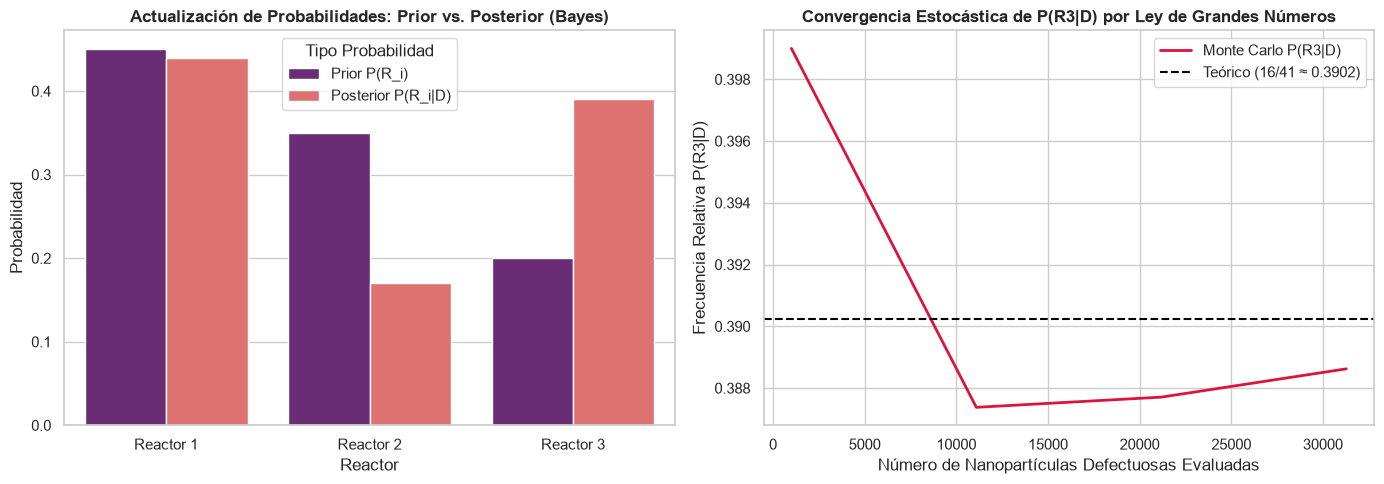

In [15]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## --- PARTE A: Combinatoria y Probabilidad Clásica ---
n_lote = 20
r_muestra = 5
total_combinaciones = math.comb(n_lote, r_muestra)
total_permutaciones = math.perm(n_lote, r_muestra)

print(f"Combinaciones C(20, 5) para seleccionar nanopartículas: {total_combinaciones}")
print(f"Permutaciones P(20, 5) considerando orden de medición: {total_permutaciones}")

## --- PARTE B: Simulación Monte Carlo del Teorema de Bayes ---
N_simulaciones = 1_000_000

## Asignación de reactores según prioris: R1=0, R2=1, R3=2
reactores = np.random.choice([1, 2, 3], size=N_simulaciones, p=[0.45, 0.35, 0.20])

## Generación de defectos según verosimilitud de cada reactor
prob_defecto_segun_reactor = np.where(reactores == 1, 0.04,
                              np.where(reactores == 2, 0.02, 0.08))

defectuosas = np.random.rand(N_simulaciones) < prob_defecto_segun_reactor

## Filtrado Bayesiano: Condicionar a las nanopartículas que resultaron defectuosas
solo_defectuosas = reactores[defectuosas]

p_r1_d_sim = np.mean(solo_defectuosas == 1)
p_r2_d_sim = np.mean(solo_defectuosas == 2)
p_r3_d_sim = np.mean(solo_defectuosas == 3)

print("\n--- RESULTADOS SIMULACIÓN MONTE CARLO (1,000,000 partículas) ---")
print(f"P(R1|D) Simulado: {p_r1_d_sim:.5f} | Teórico: {0.0180/0.0410:.5f}")
print(f"P(R2|D) Simulado: {p_r2_d_sim:.5f} | Teórico: {0.0070/0.0410:.5f}")
print(f"P(R3|D) Simulado: {p_r3_d_sim:.5f} | Teórico: {0.0160/0.0410:.5f}")

## --- PARTE C: Visualización Profesional ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Gráfico 1: Comparación Prior vs. Posterior
df_bayes = pd.DataFrame({
    'Reactor': ['Reactor 1', 'Reactor 2', 'Reactor 3'],
    'Prior P(R_i)': [0.45, 0.35, 0.20],
    'Posterior P(R_i|D)': [0.0180/0.0410, 0.0070/0.0410, 0.0160/0.0410]
})

df_melted = df_bayes.melt(id_vars='Reactor', var_name='Tipo Probabilidad', value_name='Probabilidad')
sns.barplot(data=df_melted, x='Reactor', y='Probabilidad', hue='Tipo Probabilidad', palette='magma', ax=axes[0])
axes[0].set_title("Actualización de Probabilidades: Prior vs. Posterior (Bayes)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Probabilidad")

## Gráfico 2: Simulación de Convergencia Monte Carlo
pasos_sim = np.linspace(1000, N_simulaciones, 100, dtype=int)
convergencia_r3 = [np.mean(solo_defectuosas[:n] == 3) for n in pasos_sim if n <= len(solo_defectuosas)]
pasos_validos = pasos_sim[:len(convergencia_r3)]

axes[1].plot(pasos_validos, convergencia_r3, color='crimson', label='Monte Carlo P(R3|D)', linewidth=2)
axes[1].axhline(y=16/41, color='black', linestyle='--', label=f'Teórico (16/41 ≈ {16/41:.4f})')
axes[1].set_title("Convergencia Estocástica de P(R3|D) por Ley de Grandes Números", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Número de Nanopartículas Defectuosas Evaluadas")
axes[1].set_ylabel("Frecuencia Relativa P(R3|D)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Interpretación Post-Gráfico & Diccionario de Variables

### 8.1 Interpretación de Resultados Computacionales
1. **Actualización Bayesiana de Creencias**: En el gráfico de barra comparativo se aprecia el efecto directo del Teorema de Bayes. Aunque el **Reactor 1** dominaba la producción a priori con un $45\%$, su baja tasa de defectos ($4\%$) reduce su responsabilidad a posteriori al $43.9\%$. Por el contrario, el **Reactor 3**, que solo producía el $20\%$ de las nanopartículas, pasa a representar casi el $39.02\%$ de todas las piezas defectuosas debido a su alta tasa de falla ($8\%$).
2. **Convergencia Monte Carlo**: El segundo gráfico demuestra empíricamente la Ley de los Grandes Números. Al incrementar el tamaño muestral de la simulación hacia $1,000,000$ de ensayos, la frecuencia relativa simulada converge con precisión de tres decimales hacia el valor teórico de $\frac{16}{41} \approx 0.39024$.

### 8.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1-4 y 5.6, independiente del ejemplo aplicado específico:

* $\mathcal{E}$: experimento aleatorio.
* $\Omega$: espacio muestral (conjunto de todos los resultados posibles).
* $A, B \subseteq \Omega$: eventos o sucesos (subconjuntos del espacio muestral).
* $A \cup B$: unión de eventos (ocurre al menos uno).
* $A \cap B$: intersección de eventos (ocurren ambos).
* $A^c$ o $\bar{A}$: complemento de un evento.
* $\emptyset$: evento imposible o conjunto vacío.
* $P: \mathcal{F} \rightarrow [0,1]$: función de probabilidad definida sobre los eventos.
* $P(A)$: probabilidad del evento $A$.
* $n!$: factorial de $n$, número de permutaciones de $n$ objetos distintos.
* $P(n)$: permutaciones de $n$ objetos distintos.
* $P(n, r)$: permutaciones de $n$ objetos tomados de $r$ en $r$.
* $P(n; n_1, n_2, \dots, n_k)$: permutaciones con repetición (multiset) de $n$ objetos agrupados en $k$ tipos.
* $\binom{n}{r}$ o $C(n, r)$: combinaciones de $n$ objetos tomados de $r$ en $r$ (el orden no importa).
* $P(A|B)$: probabilidad condicional de $A$ dado que ocurrió $B$.
* $A_1, A_2, \dots, A_k$: partición del espacio muestral $\Omega$ (eventos mutuamente excluyentes cuya unión es $\Omega$).
* $P(A_j)$: probabilidad a priori de la hipótesis o causa $A_j$.
* $P(B|A_j)$: verosimilitud (likelihood) de observar la evidencia $B$ bajo la hipótesis $A_j$.
* $P(A_j|B)$: probabilidad a posteriori de $A_j$ dada la evidencia $B$ (Teorema de Bayes).

### 8.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $R_1, R_2, R_3$: Eventos que representan el reactor químico de síntesis coloidal de origen.
* $D$: Evento binario que indica si una nanopartícula se encuentra defectuosa (fuera del rango de tamaño óptimo $15 \pm 2\text{ nm}$).
* $P(R_i)$: Probabilidad a priori de selección de una nanopartícula del reactor $i$.
* $P(D|R_i)$: Verosimilitud de falla por imperfección térmica en el reactor $i$.
* $P(R_i|D)$: Probabilidad a posteriori inferida mediante diagnóstico microscópico TEM.

## Errores Comunes / Misconceptions

* **Error**: Calcular $P(A \cap B) = P(A) \times P(B)$ sin verificar que $A$ y $B$ sean independientes.
  **Correcto**: la regla del producto simple solo aplica bajo independencia; en general $P(A \cap B) = P(A) \times P(B|A)$. Confundirlas subestima o sobrestima sistemáticamente la probabilidad conjunta cuando existe dependencia real entre eventos.

* **Error**: Al aplicar el Teorema de Bayes, invertir $P(A|B)$ con $P(B|A)$ asumiendo que son iguales o intercambiables.
  **Correcto**: $P(A|B) = \dfrac{P(B|A)\,P(A)}{P(B)}$ — ambas cantidades solo coinciden cuando $P(A) = P(B)$. Ignorar la probabilidad a priori $P(A)$ (el "prior") es el error clásico de razonamiento bayesiano conocido como *base rate fallacy*.

* **Error**: Tratar "eventos mutuamente excluyentes" y "eventos independientes" como sinónimos o como conceptos compatibles en el caso general.
  **Correcto**: si $A$ y $B$ son mutuamente excluyentes ($A \cap B = \emptyset$) y ambos tienen probabilidad positiva, entonces necesariamente son dependientes, porque $P(A \cap B) = 0 \neq P(A)\,P(B)$. Son propiedades distintas que rara vez coexisten.

* **Error**: Asumir que, al descartar una de $k$ opciones igualmente probables mediante evidencia adicional, la probabilidad restante se reparte equitativamente entre las opciones sobrevivientes (falacia del "50/50 automático").
  **Correcto**: como demuestra el Problema de los Tres Prisioneros (§5.6), la forma en que se genera la evidencia determina cómo se redistribuye la probabilidad — si la evidencia es más probable bajo una hipótesis que bajo otra ($P(G_B|C)=1$ vs. $P(G_B|A)=1/2$), la redistribución es asimétrica. Repartir siempre por igual ignora la verosimilitud de la evidencia bajo cada hipótesis.

## Preguntas de Concepto

**Pregunta 1.** Se sabe que $P(A) = 0.4$ y $P(B) = 0.3$, pero no se sabe si $A$ y $B$ son independientes. ¿Es correcto afirmar que $P(A \cap B) = 0.4 \times 0.3 = 0.12$?

A) Sí, la regla del producto simple siempre aplica entre dos eventos cualesquiera.
B) Sí, porque $P(A) + P(B) < 1$.
C) No, porque $P(A \cap B)$ siempre debe ser mayor que $P(A)$ y $P(B)$.
D) No, la regla $P(A \cap B) = P(A)P(B)$ solo es válida si $A$ y $B$ son independientes; en general se necesita $P(A)P(B|A)$.

**Pregunta 2.** En el Teorema de Bayes, ¿bajo qué condición $P(A|B)$ es igual a $P(B|A)$?

A) Siempre, son la misma cantidad expresada de dos formas.
B) Nunca, son conceptos incompatibles.
C) Solo cuando $P(A) = P(B)$.
D) Solo cuando $A$ y $B$ son mutuamente excluyentes.

**Pregunta 3.** Si $A$ y $B$ son eventos mutuamente excluyentes (es decir, $A \cap B = \emptyset$) y ambos tienen probabilidad positiva, ¿qué se puede afirmar sobre su independencia?

A) Son necesariamente dependientes, porque $P(A \cap B) = 0 \neq P(A)P(B)$.
B) Son necesariamente independientes, porque no comparten resultados.
C) No se puede determinar sin más información.
D) Son independientes solo si $P(A) = P(B)$.

**Pregunta 4.** Un problema tipo "Tres Prisioneros": de tres opciones igualmente probables se descarta una mediante evidencia adicional. ¿Es correcto asumir que la probabilidad restante se reparte automáticamente por igual entre las dos opciones sobrevivientes?

A) Sí, siempre que se descarte una opción el 50/50 es la única distribución posible.
B) Sí, porque la probabilidad total siempre debe sumar 1.
C) No necesariamente — depende de cómo se generó la evidencia; si la evidencia es más verosímil bajo una hipótesis que bajo otra, la redistribución es asimétrica.
D) No, la probabilidad de las opciones sobrevivientes siempre baja a cero.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [16]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "D", 2: "C", 3: "A", 4: "C"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/4 preguntas correctas


## Ejercicio Propuesto

Una planta de síntesis de puntos cuánticos (Quantum Dots, QDs) de CdSe produce su lote diario en tres líneas de reacción, $L_1$, $L_2$ y $L_3$, con las siguientes proporciones de producción y tasas de defecto (fuera de especificación de emisión fotoluminiscente):

| Línea | Proporción de producción $P(L_i)$ | Tasa de defecto $P(D\mid L_i)$ |
|:---:|:---:|:---:|
| $L_1$ | $0.50$ | $0.03$ |
| $L_2$ | $0.30$ | $0.06$ |
| $L_3$ | $0.20$ | $0.10$ |

1. Calcula la probabilidad total $P(D)$ de que un QD elegido al azar del lote unificado sea defectuoso.
2. Aplica el Teorema de Bayes para calcular $P(L_2 \mid D)$ y $P(L_3 \mid D)$.
3. De un lote de 15 QDs, ¿cuántas combinaciones distintas de 4 QDs pueden seleccionarse para control de calidad ($C(15,4)$)?

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado — Regla de la Cadena con 3+ eventos)

Un lote de control de calidad contiene $52$ nanopartículas de oro (AuNPs) recién sintetizadas, de las cuales $12$ presentan aglomeración fuera de especificación (detectada por microscopía TEM previa). Se extraen $3$ nanopartículas **sin reemplazo** para inspección destructiva. ¿Cuál es la probabilidad de que las tres extraídas estén aglomeradas? Generaliza la Regla General del Producto de la Sección 3.1 (que solo cubre 2 eventos) a tres eventos encadenados:
$$P(A_1 \cap A_2 \cap A_3) = P(A_1) \cdot P(A_2|A_1) \cdot P(A_3|A_1 \cap A_2)$$
donde cada factor refleja que el lote tiene una nanopartícula menos, y una aglomerada menos, tras cada extracción. Calcula cada una de las tres probabilidades condicionales de la cadena por separado antes de multiplicarlas.

### Ejercicio 3 (intermedio — Independencia con/sin reemplazo)

Una urna de control de calidad contiene $6$ canicas que representan nanopartículas conformes y $4$ que representan nanopartículas defectuosas. Se extraen dos canicas. Calcula $P(\text{ambas conformes})$ en dos escenarios: (a) con reemplazo, (b) sin reemplazo. Determina en cuál de los dos escenarios las extracciones son eventos independientes, en términos de si $P(\text{2da conforme} \mid \text{1ra conforme})$ cambia respecto a $P(\text{2da conforme})$.

### Ejercicio 4 (abierto — Partición de tres categorías, nanotecnología)

Un laboratorio de síntesis de nanopartículas lipídicas para liberación de fármacos produce partículas con carga superficial positiva ($40\%$), negativa ($35\%$) o neutra ($25\%$), medida por potencial zeta. La tasa de agregación no deseada (formación de agregados que invalidan el lote) es del $12\%$ para carga positiva, $5\%$ para carga negativa y $20\%$ para carga neutra. Si una nanopartícula elegida al azar del lote unificado presenta agregación, calcula la probabilidad total de agregación y la probabilidad de que su carga superficial haya sido neutra dado que presentó agregación. Compara la estructura de este ejercicio con el ejemplo de los reactores de la Sección 5 — es la misma técnica (partición de 3 categorías + Bayes) aplicada a un dataset distinto.

## Referencias

* Chan, S. H. (2021). *Introduction to Probability for Data Science*. Michigan Publishing. Capítulos sobre fundamentos de probabilidad, combinatoria y Teorema de Bayes.
* Chien, C.-F., Hsu, S.-C. & Chen, Y.-J. (2023). Bayesian decision analysis for optimizing in-line metrology and defect inspection strategy for sustainable semiconductor manufacturing and an empirical study. *Computers & Industrial Engineering*, 186, 109421. DOI: [10.1016/j.cie.2023.109421](https://doi.org/10.1016/j.cie.2023.109421) — modelo de decisión bayesiano aplicado a inspección de defectos en manufactura de semiconductores, el mismo tipo de razonamiento (Bayes + priors por reactor) del ejemplo aplicado de esta unidad.
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre probabilidad y combinatoria citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común en vez de darte la respuesta directa:

In [17]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 2] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿cuál es la diferencia entre una permutación y una combinación al contar arreglos?"))


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3741.27it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Fallo al invocar al modelo Gemini
Traceback (most recent call last):
  File "C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\src\multiagent_core\stats_tutor_agent.py", line 503, in ask
    response = client.models.generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 6550, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 4978, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\_api_client.py", line 1747, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats

Error al invocar al modelo Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No se pudo generar una respuesta. Intenta de nuevo en unos momentos.


No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [18]:
%%writefile solucion_ejercicio_u2.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
from math import comb

p_linea = {"L1": 0.50, "L2": 0.30, "L3": 0.20}
p_defecto_dado_linea = {"L1": 0.03, "L2": 0.06, "L3": 0.10}

# TODO: calcula la probabilidad total P(D) de que un QD elegido al azar sea defectuoso
#       y guárdala en `p_defecto`
# TODO: aplica el Teorema de Bayes para calcular P(L2 | D) y P(L3 | D)
#       y guárdalas en `p_l2_dado_d` y `p_l3_dado_d`
# TODO: calcula C(15, 4), el número de combinaciones de 4 QDs de un lote de 15 para
#       control de calidad, y guárdalo en `combinaciones`


Writing solucion_ejercicio_u2.py


In [19]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u2.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
from math import comb

p_linea = {"L1": 0.50, "L2": 0.30, "L3": 0.20}
p_defecto_dado_linea = {"L1": 0.03, "L2": 0.06, "L3": 0.10}

# TODO: calcula la probabilidad total P(D) de que un QD elegido al azar sea defectuoso
#       y guárdala en `p_defecto`
# TODO: aplica el Teorema de Bayes para calcular P(L2 | D) y P(L3 | D)
#       y guárdalas en `p_l2_dado_d` y `p_l3_dado_d`
# TODO: calcula C(15, 4), el número de combinaciones de 4 QDs de un lote de 15 para
#       control de calidad, y guárdalo en `combinaciones`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p_defecto", "p_l2_dado_d", "p_l3_dado_d", "combinaciones"],
    checks=[
        "abs(p_defecto - 0.053) < 1e-6",
        "abs(p_l2_dado_d - (0.30*0.06/0.053)) < 1e-6",
        "abs(p_l3_dado_d - (0.20*0.10/0.053)) < 1e-6",
        "combinaciones == 1365",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 2",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 2?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio Propuesto) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 2

In [20]:
%%writefile solucion_ejercicio2_u2.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
from fractions import Fraction

# TODO: calcula, como Fraction, cada probabilidad condicional de la cadena de 3 extracciones
#       sin reemplazo (12 AuNPs aglomeradas en un lote de 52) y guárdalas en `p1`, `p2`, `p3`
# TODO: multiplica las tres para obtener la probabilidad de que las 3 AuNPs extraídas estén
#       aglomeradas y guárdala en `p_tres_aglomeradas`


Writing solucion_ejercicio2_u2.py


In [21]:
with open("solucion_ejercicio2_u2.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
from fractions import Fraction

# TODO: calcula, como Fraction, cada probabilidad condicional de la cadena de 3 extracciones
#       sin reemplazo (12 AuNPs aglomeradas en un lote de 52) y guárdalas en `p1`, `p2`, `p3`
# TODO: multiplica las tres para obtener la probabilidad de que las 3 AuNPs extraídas estén
#       aglomeradas y guárdala en `p_tres_aglomeradas`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p1", "p2", "p3", "p_tres_aglomeradas"],
    checks=[
        "abs(float(p1) - 12/52) < 1e-6",
        "abs(float(p2) - 11/51) < 1e-6",
        "abs(float(p3) - 10/50) < 1e-6",
        "abs(float(p_tres_aglomeradas) - 11/1105) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 2",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 2?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 2) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 3

In [22]:
%%writefile solucion_ejercicio3_u2.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.

# Urna: 6 nanopartículas conformes, 4 defectuosas (10 en total)

# TODO: calcula P(ambas conformes) CON reemplazo y guárdala en `p_con_reemplazo`
# TODO: calcula P(ambas conformes) SIN reemplazo y guárdala en `p_sin_reemplazo`
# TODO: calcula P(2da conforme | 1ra conforme) SIN reemplazo y guárdala en
#       `p_condicional_sin_reemplazo`
# TODO: determina si las extracciones son independientes en cada escenario comparando
#       P(2da conforme | 1ra conforme) contra P(2da conforme); guarda booleanos en
#       `es_independiente_con_reemplazo` y `es_independiente_sin_reemplazo`


Writing solucion_ejercicio3_u2.py


In [23]:
with open("solucion_ejercicio3_u2.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.

# Urna: 6 nanopartículas conformes, 4 defectuosas (10 en total)

# TODO: calcula P(ambas conformes) CON reemplazo y guárdala en `p_con_reemplazo`
# TODO: calcula P(ambas conformes) SIN reemplazo y guárdala en `p_sin_reemplazo`
# TODO: calcula P(2da conforme | 1ra conforme) SIN reemplazo y guárdala en
#       `p_condicional_sin_reemplazo`
# TODO: determina si las extracciones son independientes en cada escenario comparando
#       P(2da conforme | 1ra conforme) contra P(2da conforme); guarda booleanos en
#       `es_independiente_con_reemplazo` y `es_independiente_sin_reemplazo`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=[
        "p_con_reemplazo",
        "p_sin_reemplazo",
        "p_condicional_sin_reemplazo",
        "es_independiente_con_reemplazo",
        "es_independiente_sin_reemplazo",
    ],
    # Un enfoque ingenuo plausible es tratar "sin reemplazo" igual que "con reemplazo"
    # (olvidar que la urna pierde una canica): eso da 0.36 en vez de 1/3 y falla el check.
    # `p_condicional_sin_reemplazo` (5/9 ≈ 0.5556) exige el cálculo real que sustenta el
    # booleano de independencia: adivinar True/False sin resolverlo ya no basta.
    checks=[
        "abs(p_con_reemplazo - 0.36) < 1e-6",
        "abs(p_sin_reemplazo - 1/3) < 1e-6",
        "abs(p_condicional_sin_reemplazo - 5/9) < 1e-6",
        "es_independiente_con_reemplazo is True",
        "es_independiente_sin_reemplazo is False",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 2",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 2?
    El archivo está vacío, es solo comentarios, o es un `pass`.

--- Detalle técnico (Ejercicio 3) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['El archivo está vacío, es solo comentarios, o es un `pass`.'])


### Autoevaluación del Ejercicio 4

In [24]:
%%writefile solucion_ejercicio4_u2.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.

p_carga = {"positiva": 0.40, "negativa": 0.35, "neutra": 0.25}
p_agregacion_dado_carga = {"positiva": 0.12, "negativa": 0.05, "neutra": 0.20}

# TODO: calcula la probabilidad total de agregación P(Agregación) y guárdala en `p_agregacion`
# TODO: aplica Bayes para calcular P(neutra | Agregación) y guárdala en `p_neutra_dado_agregacion`


Writing solucion_ejercicio4_u2.py


In [25]:
with open("solucion_ejercicio4_u2.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.

p_carga = {"positiva": 0.40, "negativa": 0.35, "neutra": 0.25}
p_agregacion_dado_carga = {"positiva": 0.12, "negativa": 0.05, "neutra": 0.20}

# TODO: calcula la probabilidad total de agregación P(Agregación) y guárdala en `p_agregacion`
# TODO: aplica Bayes para calcular P(neutra | Agregación) y guárdala en `p_neutra_dado_agregacion`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p_agregacion", "p_neutra_dado_agregacion"],
    # Un error común plausible es reportar el prior P(neutra)=0.25 en vez del posterior:
    # el check con el valor de Bayes (0.4329...) distingue ambos casos.
    checks=[
        "abs(p_agregacion - 0.1155) < 1e-6",
        "abs(p_neutra_dado_agregacion - 0.4329004329004329) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 2",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 2?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 4) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])
